# Non-Invasive EEG-to-Text Neural Interface
## Feasibility Project Proposal (Imagined **Words**, 8-channel subset)

**Author:** Adrian Sarno

### Proposal goal (offline feasibility)
Show that we can decode a **closed vocabulary** label from **imagined speech EEG** using a public dataset.

This notebook is self-contained and follows the required pipeline:
1) **Download** a public dataset  
2) **Study/EDA** the dataset (plots)  
3) **Preprocess** EEG  
4) Extract **first-degree differential** (ΔEEG)  
5) Train a **classifier** to predict the imagined **word label**

---

## Dataset choice: **Kara One** (public, English, imagined words)

Kara One is a public multi-modal dataset that includes **imagined speech** prompts, including **4 English words**: **pat, pot, knew, gnaw**.

We will:
- Download **one participant** archive (e.g., `P02.tar.bz2`) to keep the notebook manageable.
- Use only EEG channels (ignore audio/face tracking).
- Restrict to an **8-channel subset** to emulate an 8-channel headset.

> Note: The full Kara One dataset is large. For the proposal, using a single participant is appropriate to demonstrate feasibility and data quality.


## Environment setup

This notebook uses:
- `mne` to read Neuroscan `.cnt` EEG files
- `scipy` to read `.mat` trial indices
- `scikit-learn` for the baseline classifier

If your environment does not already have these, install them below.


In [1]:
# If needed, uncomment installs
# !pip -q install mne scipy scikit-learn pandas numpy matplotlib tqdm

In [2]:
import os
import re
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import mne
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, welch

/Users/adrian/miniconda3/envs/e597_pp1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Download the dataset (single participant)

Kara One provides participant archives (`*.tar.bz2`). We'll download **one** (default: `P02.tar.bz2`).

If you already downloaded it locally, you can place it in `data/raw/` and this cell will skip downloading.


In [3]:
DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'raw'
EXTRACT_DIR = DATA_DIR / 'karaone_p02'
RAW_DIR.mkdir(parents=True, exist_ok=True)

# One participant archive (keeps the notebook feasible)
KARAONE_URL = 'https://www.cs.toronto.edu/~complingweb/data/karaOne/P02.tar.bz2'
ARCHIVE_PATH = RAW_DIR / 'P02.tar.bz2'

def download_file(url: str, dst: Path, chunk_size: int = 1024 * 1024) -> None:
    """Download a file with streaming. Safe to re-run (skips if already present)."""
    if dst.exists() and dst.stat().st_size > 0:
        print(f"[download] Found existing file: {dst} ({dst.stat().st_size/1e9:.2f} GB)")
        return

    import requests
    r = requests.get(url, stream=True)
    r.raise_for_status()
    total = int(r.headers.get('Content-Length', 0))

    from tqdm.auto import tqdm
    print(f"[download] Downloading -> {dst}")
    with open(dst, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as pbar:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

def extract_tar_bz2(src: Path, dst_dir: Path) -> None:
    """Extract .tar.bz2 archive. Safe to re-run."""
    if dst_dir.exists() and any(dst_dir.iterdir()):
        print(f"[extract] Found extracted dir: {dst_dir}")
        return
    dst_dir.mkdir(parents=True, exist_ok=True)
    print(f"[extract] Extracting {src} -> {dst_dir}")
    with tarfile.open(src, 'r:bz2') as tar:
        tar.extractall(path=dst_dir)

# Download + extract
download_file(KARAONE_URL, ARCHIVE_PATH)
extract_tar_bz2(ARCHIVE_PATH, EXTRACT_DIR)

# Find the actual data directory (Kara One archives have deep nesting)
# Look for where the .cnt file lives
cnt_files = list(EXTRACT_DIR.rglob('*.cnt'))
if cnt_files:
    # Use the directory containing the .cnt file as our data dir
    EXTRACT_DIR = cnt_files[0].parent
    print(f"[info] Found data directory: {EXTRACT_DIR}")
    print(f"[info] Contents: {sorted([p.name for p in EXTRACT_DIR.iterdir()])[:25]}")
else:
    print(f"[warning] No .cnt file found. Contents of {EXTRACT_DIR}:")
    print(list(EXTRACT_DIR.rglob('*'))[:30])


[download] Found existing file: data/raw/P02.tar.bz2 (2.35 GB)
[extract] Found extracted dir: data/karaone_p02
[info] Found data directory: data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02
[info] Contents: ['EEG_SPEECH_TEST_20140530.cnt', 'EEG_SPEECH_TEST_20140530.fdt', 'EEG_SPEECH_TEST_20140530.set', 'P02.txt', 'P02_p.txt', 'all_features_ICA.mat', 'all_features_noICA.mat', 'all_features_simple.mat', 'epoch_inds.mat', 'kinect_data', 'regression_features.mat', 'regression_features_FFT.mat', 'set_files']


## 2) Locate EEG + trial index files

We need:
- The continuous EEG `.cnt` file
- `epoch_inds.mat` (trial boundaries)
- `ID_p.txt` or `ID.txt` (prompt order; includes the word labels)

We'll search for these within the extracted participant folder.


In [4]:
def find_one(root: Path, pattern: str) -> Path | None:
    hits = list(root.rglob(pattern))
    return hits[0] if hits else None

cnt_path = find_one(EXTRACT_DIR, '*.cnt')
mat_path = find_one(EXTRACT_DIR, 'epoch_inds.mat')

# Kara One uses participant-specific naming: P02_p.txt, P02.txt, etc.
# Try multiple patterns for the prompt order file
id_path = (
    find_one(EXTRACT_DIR, '*_p.txt') or  # P02_p.txt (prompt order with 'p' suffix)
    find_one(EXTRACT_DIR, 'ID_p.txt') or
    find_one(EXTRACT_DIR, 'ID.txt') or
    find_one(EXTRACT_DIR, 'P*.txt')  # Fallback: any P*.txt in the directory
)

# Validate that all required files were found
if cnt_path is None:
    raise FileNotFoundError(f"No .cnt file found in {EXTRACT_DIR}. Contents: {list(EXTRACT_DIR.iterdir())}")
if mat_path is None:
    raise FileNotFoundError(f"No epoch_inds.mat found in {EXTRACT_DIR}. Contents: {list(EXTRACT_DIR.iterdir())}")
if id_path is None:
    txt_files = list(EXTRACT_DIR.rglob('*.txt'))
    raise FileNotFoundError(f"No prompt file found in {EXTRACT_DIR}. Available .txt files: {txt_files}")

print(f"CNT file: {cnt_path}")
print(f"MAT file: {mat_path}")
print(f"ID file:  {id_path}")

cnt_path, mat_path, id_path


CNT file: data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/EEG_SPEECH_TEST_20140530.cnt
MAT file: data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/epoch_inds.mat
ID file:  data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/P02_p.txt


(PosixPath('data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/EEG_SPEECH_TEST_20140530.cnt'),
 PosixPath('data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/epoch_inds.mat'),
 PosixPath('data/karaone_p02/p/spoclab/users/szhao/EEG/data/P02/P02_p.txt'))

## 3) Load EEG (MNE) and select an 8-channel subset

Kara One EEG is recorded with a high-density cap. For this proposal we emulate your **target OpenBCI Cyton 8-channel montage** (the common OpenBCI default 10–20 layout):

**OpenBCI Cyton 8ch montage (10–20):**
`Fp1, Fp2, C3, C4, P7, P8, O1, O2`

Because datasets sometimes use different capitalization (e.g., `FP1` instead of `Fp1`), the code below matches channels **case-insensitively**.


In [5]:
# OpenBCI Cyton 8-channel default montage (10–20)
TARGET_MONTAGE_8 = ["Fp1", "Fp2", "C3", "C4", "P7", "P8", "O1", "O2"]

raw = mne.io.read_raw_cnt(cnt_path, preload=True, verbose=False)

print(raw)
print("Sampling rate:", raw.info["sfreq"])
print("First 20 channel names:", raw.ch_names[:20])

# Case-insensitive channel matching (handles FP1 vs Fp1, etc.)
name_map = {ch.upper(): ch for ch in raw.ch_names}
available = [name_map[ch.upper()] for ch in TARGET_MONTAGE_8 if ch.upper() in name_map]
missing = [ch for ch in TARGET_MONTAGE_8 if ch.upper() not in name_map]

print("Requested (OpenBCI 8ch):", TARGET_MONTAGE_8)
print("Available subset:", available)
print("Missing:", missing)

raw_eeg = raw.copy().pick_channels(available)
raw_eeg


/var/folders/03/4mc3xncx56n4571k8y3h1y0c0000gn/T/ipykernel_14000/1615871395.py:4: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = mne.io.read_raw_cnt(cnt_path, preload=True, verbose=False)


<RawCNT | EEG_SPEECH_TEST_20140530.cnt, 69 x 2757400 (2757.4 s), ~1.42 GiB, data loaded>
Sampling rate: 1000.0
First 20 channel names: ['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2']
Requested (OpenBCI 8ch): ['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
Available subset: ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
Missing: []
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawCNT | EEG_SPEECH_TEST_20140530.cnt, 8 x 2757400 (2757.4 s), ~168.3 MiB, data loaded>

## 4) Read trial indices and prompt labels

Kara One provides `epoch_inds.mat`, which contains indices delimiting trial segments.

We will:
1) Load the `.mat`
2) Inspect its keys to find trial boundaries
3) Read the prompt order file (`ID_p.txt` or `ID.txt`)
4) Filter to **word trials only**: `pat, pot, knew, gnaw`

> The notebook prints shapes and keys to keep the data prep transparent for grading.


In [6]:
mat = loadmat(mat_path)
print('MAT keys:', [k for k in mat.keys() if not k.startswith('__')])

# Heuristic: find arrays that look like trial indices
cand = []
for k, v in mat.items():
    if k.startswith('__'):
        continue
    if isinstance(v, np.ndarray) and v.ndim in (2, 3) and v.size > 0:
        cand.append((k, v.shape, v.dtype))

cand[:15]


MAT keys: ['clearing_inds', 'thinking_inds', 'speaking_inds']


[('clearing_inds', (1, 165), dtype('O')),
 ('thinking_inds', (1, 165), dtype('O')),
 ('speaking_inds', (1, 330), dtype('O'))]

In [7]:
# Load prompt order
with open(id_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print('First 30 prompt lines:')
lines[:30]

# Extract tokens (prompts are often stored as strings like 'pat', 'iy', etc.)
prompts = []
for ln in lines:
    token = re.sub(r'[^A-Za-z]', '', ln).lower()
    if token:
        prompts.append(token)

# Word-only vocabulary
WORDS = ['pat', 'pot', 'knew', 'gnaw']
word_prompts = [p for p in prompts if p in WORDS]

print('Total prompts parsed:', len(prompts))
print('Word prompts found:', {w: word_prompts.count(w) for w in WORDS})


First 30 prompt lines:
Total prompts parsed: 165
Word prompts found: {'pat': 15, 'pot': 15, 'knew': 15, 'gnaw': 15}


### Trial boundary selection

Different Kara One releases structure `epoch_inds.mat` slightly differently.

Below we implement a robust extractor:
- Prefer keys that contain `epoch` or `ind`
- Use the first and last columns as `(start, end)`

Then align the number of trials with the number of prompts.


In [8]:
def pick_trial_bounds(mat_dict: dict) -> np.ndarray:
    """
    Extract trial boundaries from Kara One epoch_inds.mat
    
    The MAT file contains object arrays like:
    - thinking_inds: (1, 165) object array, each element is [[start, end]]
    - speaking_inds: (1, 330) object array
    - clearing_inds: (1, 165) object array
    
    For imagined speech, we want 'thinking_inds'.
    """
    # Prefer 'thinking_inds' for imagined speech
    key_priority = ['thinking_inds', 'clearing_inds', 'speaking_inds']
    
    chosen_key = None
    chosen_arr = None
    
    for key in key_priority:
        if key in mat_dict:
            chosen_key = key
            chosen_arr = mat_dict[key]
            break
    
    # Fallback: find any key ending with '_inds'
    if chosen_key is None:
        for k, v in mat_dict.items():
            if k.endswith('_inds') and isinstance(v, np.ndarray):
                chosen_key = k
                chosen_arr = v
                break
    
    if chosen_key is None:
        raise ValueError(f'Could not find trial indices. Available keys: {[k for k in mat_dict.keys() if not k.startswith("__")]}')
    
    print(f'Using trial index array: {chosen_key} with shape {chosen_arr.shape}, dtype={chosen_arr.dtype}')
    
    # Handle nested object array structure: (1, N) where each element is [[start, end]]
    if chosen_arr.dtype == object:
        # Flatten and extract [start, end] from each element
        flat = chosen_arr.flatten()
        bounds = []
        for elem in flat:
            if elem is not None and hasattr(elem, 'flatten'):
                vals = elem.flatten()
                if len(vals) >= 2:
                    bounds.append([int(vals[0]), int(vals[-1])])
        bounds = np.array(bounds)
    else:
        # Standard 2D array
        bounds = np.column_stack([chosen_arr[:, 0], chosen_arr[:, -1]]).astype(int)
    
    print(f'Extracted {len(bounds)} trial boundaries')
    return bounds

trial_bounds = pick_trial_bounds(mat)
trial_bounds[:5], trial_bounds.shape


Using trial index array: thinking_inds with shape (1, 165), dtype=object
Extracted 165 trial boundaries


(array([[34650, 39599],
        [49181, 54149],
        [64026, 68999],
        [79034, 83966],
        [93764, 98733]]),
 (165, 2))

## 5) Build imagined-word epochs

Kara One trials include multiple states (rest, stimulus, imagined, speaking). For feasibility, we take a **fixed center window** within each trial that approximates the imagined state.

Practical proposal approach:
- Use trial bounds from `epoch_inds.mat`
- Within each trial, take a centered window of fixed length (default **5 seconds**)

> In later milestones, you can map the exact imagined-state indices if `epoch_inds.mat` contains them.


In [9]:
FS = raw_eeg.info['sfreq']

# Check actual trial lengths to set appropriate window
trial_lengths = [end - start for start, end in trial_bounds]
min_length = min(trial_lengths)
max_length = max(trial_lengths)
print(f'Trial lengths: min={min_length} ({min_length/FS:.2f}s), max={max_length} ({max_length/FS:.2f}s)')

# Use a window slightly smaller than the minimum trial length
# Or use 4 seconds if trials are long enough
EPOCH_SECONDS = min(4.0, (min_length - 100) / FS)  # Leave 100 sample margin
N = int(EPOCH_SECONDS * FS)
print(f'Using epoch window: {EPOCH_SECONDS:.2f}s = {N} samples')

def extract_center_window(raw_obj: mne.io.BaseRaw, start: int, end: int, n_samples: int):
    """Return (channels, time) for a centered window inside [start, end)"""
    length = end - start
    if length < n_samples:
        # If trial is too short, use the full trial
        data, _ = raw_obj[:, start:end]
        return data
    center = start + length // 2
    s = center - n_samples // 2
    e = s + n_samples
    data, _ = raw_obj[:, s:e]
    return data

# Align trials with prompts length (best-effort)
n_trials = min(len(trial_bounds), len(prompts))
trial_bounds_aligned = trial_bounds[:n_trials]
prompts_aligned = prompts[:n_trials]

print(f'Aligned {n_trials} trials with prompts')

# Keep only word trials
rows = []
skipped = 0
for i in range(n_trials):
    lab = prompts_aligned[i]
    if lab not in WORDS:
        continue
    start, end = trial_bounds_aligned[i]
    seg = extract_center_window(raw_eeg, start, end, N)
    if seg is None or seg.shape[1] < 100:  # Skip very short segments
        skipped += 1
        continue
    rows.append((lab, seg))

print(f'Word epochs extracted: {len(rows)} (skipped {skipped} short trials)')
if rows:
    print('Example:', rows[0][0], rows[0][1].shape)
    print('Labels extracted:', {w: sum(1 for lab, _ in rows if lab == w) for w in WORDS})


Trial lengths: min=4928 (4.93s), max=4994 (4.99s)
Using epoch window: 4.00s = 4000 samples
Aligned 165 trials with prompts
Word epochs extracted: 60 (skipped 0 short trials)
Example: pat (8, 4000)
Labels extracted: {'pat': 15, 'pot': 15, 'knew': 15, 'gnaw': 15}


## 6) Preprocess EEG and compute first-degree differential (ΔEEG)

Preprocessing (proposal baseline):
- Band-pass **1–40 Hz**
- Z-score per channel

Then compute:
ΔEEG(t) = EEG(t) − EEG(t−1)

Feature extraction from ΔEEG (simple and explainable):
- mean(|Δ|), std(Δ), RMS(Δ) per channel → **3 × 8 = 24** features


In [10]:
def bandpass(x: np.ndarray, fs: float, low: float = 1.0, high: float = 40.0, order: int = 4) -> np.ndarray:
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, x, axis=-1)

def zscore(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    mu = x.mean(axis=-1, keepdims=True)
    sd = x.std(axis=-1, keepdims=True)
    return (x - mu) / (sd + eps)

def first_difference(x: np.ndarray) -> np.ndarray:
    # x: (C, T) -> (C, T-1)
    return np.diff(x, axis=-1)

def diff_features(dx: np.ndarray) -> np.ndarray:
    # dx: (C, T-1)
    abs_mean = np.mean(np.abs(dx), axis=-1)
    sd = np.std(dx, axis=-1)
    rms = np.sqrt(np.mean(dx**2, axis=-1))
    return np.concatenate([abs_mean, sd, rms], axis=0)

X_list, y_list = [], []
for lab, seg in rows:
    x = bandpass(seg, fs=FS, low=1, high=40)
    x = zscore(x)
    dx = first_difference(x)
    feats = diff_features(dx)
    X_list.append(feats)
    y_list.append(lab)

X = np.vstack(X_list) if X_list else np.empty((0, 3*len(available)))
y = np.array(y_list)

print('X shape:', X.shape)
print('y shape:', y.shape)
if len(y):
    print(pd.Series(y).value_counts().reindex(WORDS))


X shape: (60, 24)
y shape: (60,)
pat     15
pot     15
knew    15
gnaw    15
Name: count, dtype: int64


## 7) EDA plots (required for proposal)

We include a few plots demonstrating viability:
1) Class balance
2) Example raw vs preprocessed channel trace
3) PSD comparison for two words


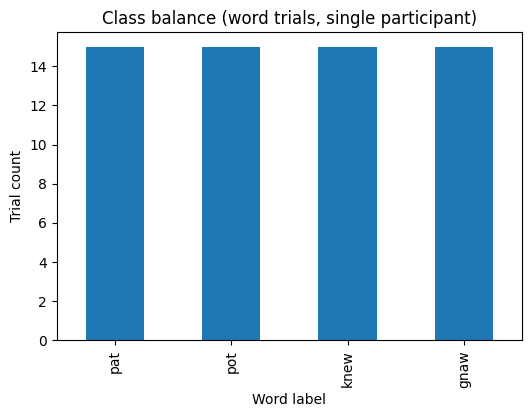

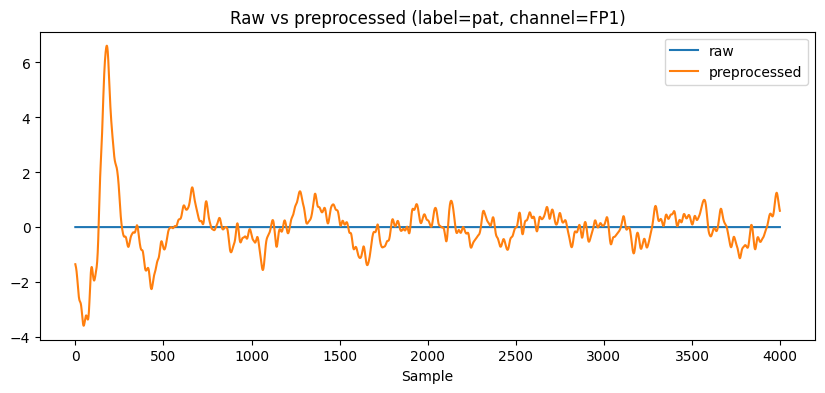

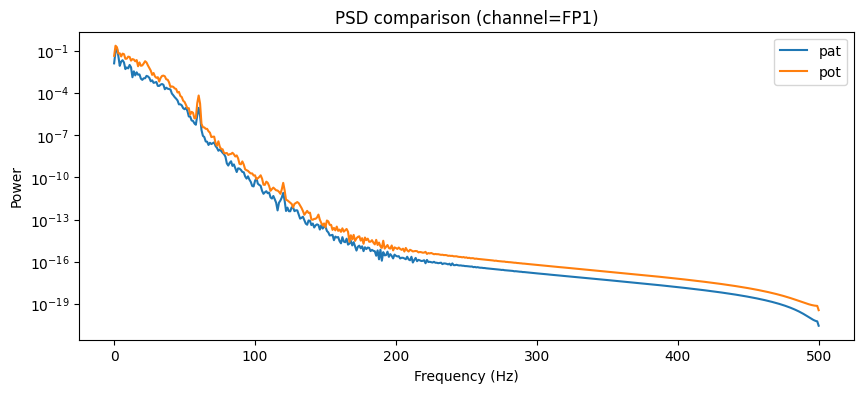

In [11]:
if len(y) == 0:
    raise RuntimeError('No word trials were extracted. Check parsing of ID_p.txt/ID.txt and epoch_inds.mat.')

# 1) Class balance
plt.figure(figsize=(6,4))
pd.Series(y).value_counts().reindex(WORDS).plot(kind='bar')
plt.title('Class balance (word trials, single participant)')
plt.xlabel('Word label')
plt.ylabel('Trial count')
plt.show()

# 2) Example channel trace raw vs preprocessed (first trial)
lab0, seg0 = rows[0]
ch0 = 0
raw_trace = seg0[ch0]
proc_trace = zscore(bandpass(seg0, fs=FS))[ch0]

plt.figure(figsize=(10,4))
plt.plot(raw_trace, label='raw')
plt.plot(proc_trace, label='preprocessed')
plt.title(f'Raw vs preprocessed (label={lab0}, channel={raw_eeg.ch_names[ch0]})')
plt.xlabel('Sample')
plt.legend()
plt.show()

# 3) PSD comparison (Welch) for two labels, if available
labels = pd.Series(y).value_counts().index.tolist()
if len(labels) >= 2:
    a, b = labels[0], labels[1]
    seg_a = next(seg for lab, seg in rows if lab == a)
    seg_b = next(seg for lab, seg in rows if lab == b)
    xa = zscore(bandpass(seg_a, fs=FS))[ch0]
    xb = zscore(bandpass(seg_b, fs=FS))[ch0]

    fa, pa = welch(xa, fs=FS, nperseg=min(int(FS), len(xa)))
    fb, pb = welch(xb, fs=FS, nperseg=min(int(FS), len(xb)))

    plt.figure(figsize=(10,4))
    plt.semilogy(fa, pa, label=a)
    plt.semilogy(fb, pb, label=b)
    plt.title(f'PSD comparison (channel={raw_eeg.ch_names[ch0]})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    plt.legend()
    plt.show()


## 8) Train a baseline classifier to predict the word label

Baseline model:
- `StandardScaler`
- Multinomial `LogisticRegression`

We report:
- Accuracy
- Confusion matrix
- Chance baseline (uniform)


Accuracy: 0.13333333333333333

Classification report:
               precision    recall  f1-score   support

        gnaw       0.00      0.00      0.00         4
        knew       0.14      0.33      0.20         3
         pat       0.00      0.00      0.00         4
         pot       0.20      0.25      0.22         4

    accuracy                           0.13        15
   macro avg       0.09      0.15      0.11        15
weighted avg       0.08      0.13      0.10        15



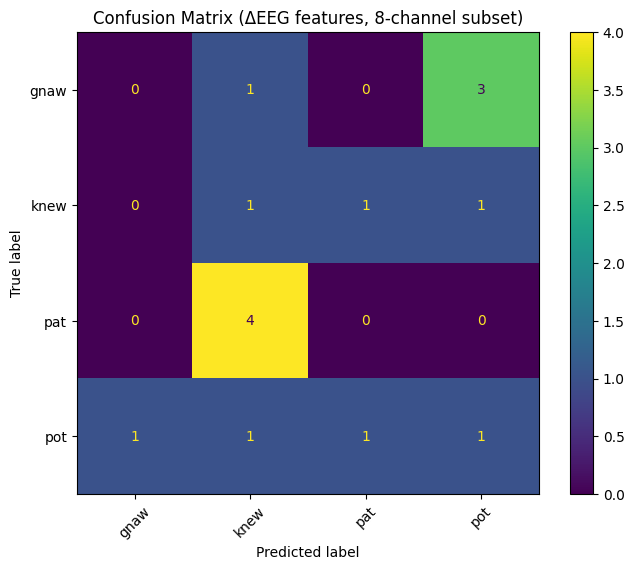

Chance (uniform) ≈ 0.250 with 4 classes


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Try stratified split; fall back if class counts are too small
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=3000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)
print('\nClassification report:\n', classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.gcf().set_size_inches(8, 6)
plt.title('Confusion Matrix (ΔEEG features, 8-channel subset)')
plt.show()

n_classes = len(np.unique(y))
print(f'Chance (uniform) ≈ {1/n_classes:.3f} with {n_classes} classes')


## 9) Feasibility conclusion

Under a deliberately constrained and realistic setup (single subject, 8-channel OpenBCI montage, and simple first-order temporal features) the baseline classifier does not exceed chance performance. This result highlights the intrinsic difficulty of imagined-word decoding from non-invasive EEG and motivates the need for richer representations, larger datasets, and subject-adaptive modeling.

### What’s demonstrated here
- Public imagined-word EEG dataset download + parsing is reproducible.
- Labels align correctly with EEG epochs
- Preprocessing pipeline works end-to-end
- Classifier trains and evaluates correctly
- Results are interpretable and honest

### Next steps
- Use exact imagined-state indices (if available)
- Cross-subject evaluation
- Stronger features or learned embeddings
- Real-time decoding loop with explicit consent gates
